# EmporiUm Sales Territory Analysis

This project analyzes sales performance for the Massachusetts sales territory in the Northeast region of EmporiUm. The territory is managed by Bo Heap. Using Python, Pandas, NumPy, and Matplotlib, sales data is cleaned, merged, and analyzed to evaluate revenue trends, store performance, customer spending, and product category sales.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
store_sales = pd.read_csv("StoreSales.csv")

store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [32]:
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [33]:
customer_list = pd.read_csv("customer_list.csv", sep="|")

customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [34]:
customer_list.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [35]:
product_categories = pd.read_csv("ProductCategories.csv")

product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [36]:
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [37]:
products = pd.read_csv("Products.csv")

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [38]:
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [39]:
store_details = pd.read_csv("StoreDetail.csv")

store_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [40]:
store_details.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


# Core Marketing Analysis

### Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?

In [41]:
bo_heap_stores = store_details[store_details["Territory Manager"] == "Bo Heap"]

bo_heap_stores

,Store Location,State,Store ID,Territory Manager,Region,Region Director
52,Boston,Massachusetts,730,Bo Heap,Northeast,Michael Jarvis
53,Attleboro,Massachusetts,801,Bo Heap,Northeast,Michael Jarvis
54,Falmouth,Massachusetts,802,Bo Heap,Northeast,Michael Jarvis
55,Framingham,Massachusetts,803,Bo Heap,Northeast,Michael Jarvis
56,Haverhill,Massachusetts,804,Bo Heap,Northeast,Michael Jarvis
57,Hingham,Massachusetts,805,Bo Heap,Northeast,Michael Jarvis
58,Holyoke,Massachusetts,806,Bo Heap,Northeast,Michael Jarvis
59,Leominster,Massachusetts,807,Bo Heap,Northeast,Michael Jarvis
60,Lowell,Massachusetts,808,Bo Heap,Northeast,Michael Jarvis
61,Lynn,Massachusetts,809,Bo Heap,Northeast,Michael Jarvis


### 2. Monthly Total Revenue for In-Store Sales

In [ ]:
# I merged sales and store data for Bo Heap
sales_with_stores = pd.merge( store_sales, store_details, on = "Store ID")

bo_heap_sales = sales_with_stores[sales_with_stores["Territory Manager"] == "Bo Heap"].copy()
# I used .copy() because pandas warned that I was modifying filtered data directly, 
# so I created a separate dataframe to help avoid accidental changes to the original data.

bo_heap_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
79,1/1/2022,803,NaN,105422-T,116.20,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis
80,1/1/2022,803,NaN,105423-M,40.55,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis
81,1/1/2022,804,NaN,105424-T,192.26,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis
82,1/1/2022,806,NaN,105345-IT,120.82,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis
83,1/1/2022,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis


In [43]:
bo_heap_sales["Transaction Date"] = pd.to_datetime(bo_heap_sales["Transaction Date"])

bo_heap_sales["Year"] = bo_heap_sales["Transaction Date"].dt.year

bo_heap_sales["Month"] = bo_heap_sales["Transaction Date"].dt.month

## I did this to create year and month columns

### What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?

In [44]:
monthly_revenue = bo_heap_sales.groupby(["Year", "Month"])["Sale Amount"].sum()

monthly_revenue

# This gives me the monthly revenue breakdown of all BO Heaps stores month by month from Jan 2022 - Dec 2025

Year  Month
2022  1         69396.42
      2         65616.00
      3         77390.00
      4         81333.60
      5         75919.64
      6         81227.82
      7         67271.23
      8         73543.48
      9         58716.74
      10        72514.81
      11        70654.73
      12        70025.64
2023  1        139388.56
      2        104454.67
      3        112443.92
      4        109369.00
      5        109021.42
      6        101710.16
      7        120793.96
      8        126212.14
      9        121968.93
      10       113824.37
      11       105670.08
      12       101641.22
2024  1        117915.05
      2        103968.70
      3        110968.54
      4        107421.88
      5        106193.39
      6        116310.73
      7        126212.14
      8        123926.20
      9        111867.10
      10       110582.18
      11        96729.12
      12       139388.56
2025  1        150745.88
      2        140234.24
      3        160846.61
      4      

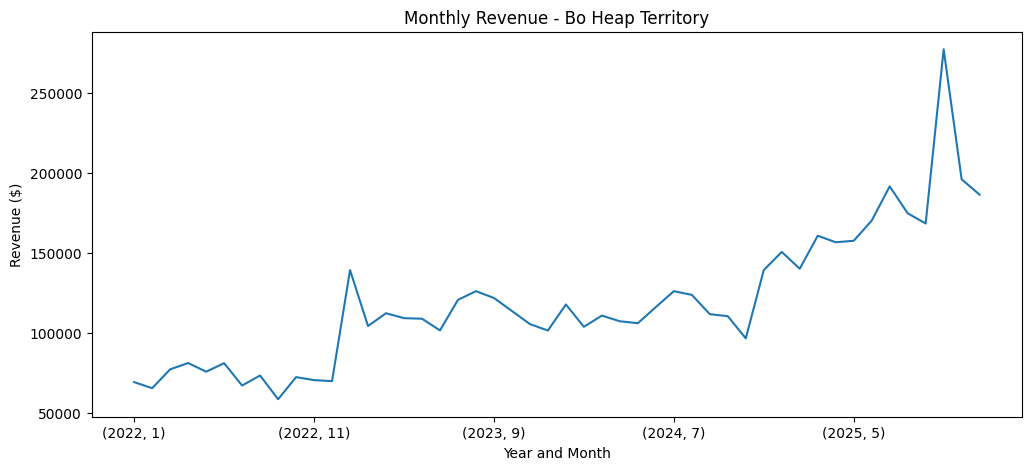

In [45]:
monthly_revenue.plot(kind = "line",figsize=(12,5))

plt.title("Monthly Revenue - Bo Heap Territory")
plt.ylabel("Revenue ($)")
plt.xlabel("Year and Month")
plt.show()

#This line chart shows the monthly revenue trend for stores in Bo Heap’s Massachusetts territory. 
# The x-axis represents the year and month of each transaction, while the y-axis shows total sales revenue. 
# I used a line chart because it makes it easier to identify trends and changes in revenue over time

In [46]:
yearly_revenue = bo_heap_sales.groupby("Year")["Sale Amount"].sum()

yearly_revenue

Year
2022     863610.11
2023    1366498.43
2024    1371483.59
2025    2131664.14
Name: Sale Amount, dtype: float64

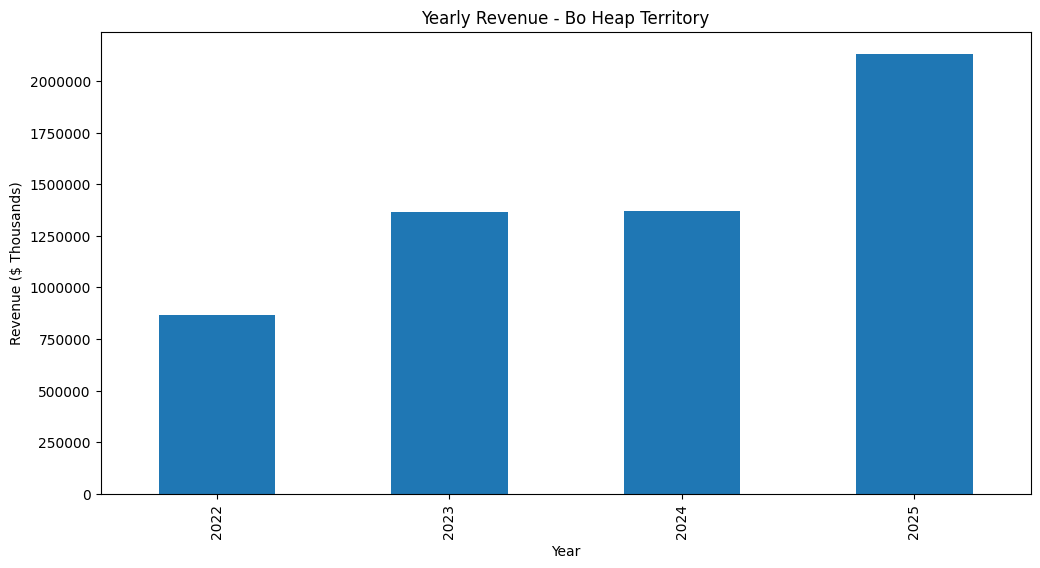

In [47]:
yearly_revenue.plot(kind="bar",figsize=(12,6))

plt.title("Yearly Revenue - Bo Heap Territory")
plt.ylabel("Revenue ($ Thousands)")
plt.xlabel("Year")

plt.ticklabel_format(style='plain', axis='y')

plt.show()

# This chart shows total yearly revenue for Bo Heap’s territory. 
# I used a bar chart because it clearly compares revenue performance between years and helps identify overall growth or decline.

### 3. How would you rank the sales performance of each store in each sales territory? Which are the top performing stores?

In [48]:
store_performance = bo_heap_sales.groupby(
    ["Store ID", "Store Location"]
    )["Sale Amount"].sum().sort_values(
         ascending = False)

store_performance

# I grouped by both Store ID and Store Location to make sure each store was ranked individually and no locations were accidentally combined.
# The top performing stores arew 817, 807, and 810

Store ID  Store Location
817       Worcester         602183.44
807       Leominster        338009.10
810       Nantucket         335547.81
814       Provincetown      328860.51
812       Northampton       322039.24
806       Holyoke           320516.53
816       Somerville        312873.59
804       Haverhill         305762.60
809       Lynn              302049.65
813       Pittsfield        301281.50
811       New Bedford       295443.42
730       Boston            295201.29
801       Attleboro         290883.71
805       Hingham           289633.52
815       Quincy            279646.07
802       Falmouth          276965.55
803       Framingham        269375.91
808       Lowell            266982.83
Name: Sale Amount, dtype: float64

### 4. Comparing the customer ID from the customer list data with the rewards ID from the sales data, who were the top customers in each sales territory?

In [49]:
customer_sales = pd.merge(bo_heap_sales,customer_list,
    left_on="RewardsID",
    right_on="cust_id")

customer_sales.head()

# To identify the top customers in Bo Heap’s territory, 
# customer information was joined with the sales data by matching the customer ID on the customer list
#  with the RewardsID from the sales transactions.

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Year,Month,cust_id,date,time,name,email,phone,sms-opt-out
0,2022-01-01,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,186,2023-02-25,09:50:20,Olivia Pope,olivia@oliviapopeandassociates.com,202-555-1201,N
1,2022-01-01,814,327.0,105427-S,10.16,Provincetown,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,327,2023-04-10,10:30:50,John Doggett,doggett@fbi.gov,202-555-1306,N
2,2022-01-02,801,243.0,105262-IT,603.50,Attleboro,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,243,2024-01-03,18:40:00,Dayanara Diaz,daya@litchfield.pen,607-555-1708,N
3,2022-01-02,817,184.0,105457-IT,29.81,Worcester,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,184,2023-12-16,21:50:15,Stan Winters,stan@wzhup.det,313-555-1109,N
4,2022-01-02,817,321.0,105365-T,221.48,Worcester,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,321,2023-08-03,20:05:20,Serenity,serenity@serenity.ship,042-555-1210,N


In [50]:
top_customers = customer_sales.groupby(["cust_id", "name"])["Sale Amount"].sum().sort_values( ascending=False)

top_customers

cust_id  name           
292      Beverly Crusher    4758.92
384      Tracy Jordan       4197.55
47       Stanley H.         3979.73
3        Monica Geller      3966.91
188      Mellie Grant       3948.41
                             ...   
389      Cerie                70.35
289      Geordi La Forge      65.97
346      Cassie Howard        46.24
438      Estelle C.           24.71
24       Arya Stark           23.17
Name: Sale Amount, Length: 521, dtype: float64

In [51]:
top_10_customers = customer_sales.groupby(["cust_id", "name"])["Sale Amount"].sum().sort_values( ascending=False).head(10)

top_10_customers

cust_id  name           
292      Beverly Crusher    4758.92
384      Tracy Jordan       4197.55
47       Stanley H.         3979.73
3        Monica Geller      3966.91
188      Mellie Grant       3948.41
300      Julian Bashir      3883.60
17       Mike E.            3788.67
316      Kaylee Frye        3725.87
344      Nate Jacobs        3569.36
178      Pamela James       3523.01
Name: Sale Amount, dtype: float64

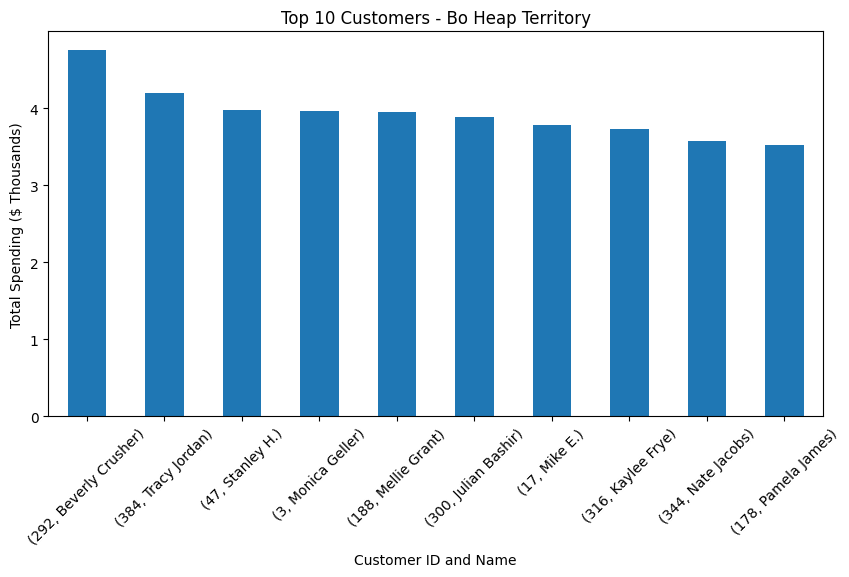

In [52]:
# This code gives top 10 customers in Massachusettes

(top_10_customers / 1000).plot( kind="bar",figsize=(10,5))

plt.title("Top 10 Customers - Bo Heap Territory")
plt.ylabel("Total Spending ($ Thousands)")
plt.xlabel("Customer ID and Name")

plt.xticks(rotation=45)

plt.show()

### 5. What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?

In [53]:
sales_products = pd.merge(bo_heap_sales,products,
    on = "Prod Num")

sales_products.head()

# merged the sales data with the product data using the 
# product number column so each transaction could be connected to a specific product.

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Year,Month,Product,CategoryID,SubcategoryID
0,2022-01-01,803,NaN,105422-T,116.20,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Abstract Algebra,100,100-mat
1,2022-01-01,803,NaN,105423-M,40.55,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,"LTCA Year Up Coasters (Set of 4, Cork)",130,130-hom
2,2022-01-01,804,NaN,105424-T,192.26,Haverhill,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Organic Chemistry I,100,100-sci
3,2022-01-01,806,NaN,105345-IT,120.82,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Razer Kraken X,120,120-hea
4,2022-01-01,806,186.0,105385-M,27.52,Holyoke,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,LTCA Year Up Foam Finger (Black),130,130-spo


In [54]:
sales_products_categories = pd.merge(sales_products,product_categories, on="CategoryID")

sales_products_categories.head()

# I merged the product data with the category data so I could analyze sales performance by product category.”

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Year,Month,Product,CategoryID,SubcategoryID_x,Category,SubcategoryID_y,Subcategory
0,2022-01-01,803,NaN,105422-T,116.2,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Abstract Algebra,100,100-mat,Textbooks,100-bus,Business & Economics
1,2022-01-01,803,NaN,105422-T,116.2,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Abstract Algebra,100,100-mat,Textbooks,100-mis,Miscellaneous Academic Topics
2,2022-01-01,803,NaN,105422-T,116.2,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Abstract Algebra,100,100-mat,Textbooks,100-eng,Engineering & Technology
3,2022-01-01,803,NaN,105422-T,116.2,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Abstract Algebra,100,100-mat,Textbooks,100-hea,Health Sciences
4,2022-01-01,803,NaN,105422-T,116.2,Framingham,Massachusetts,Bo Heap,Northeast,Michael Jarvis,2022,1,Abstract Algebra,100,100-mat,Textbooks,100-tec,Technology and Computing


In [55]:
monthly_transactions = sales_products_categories.groupby(["Year", "Month", "Category"])["Sale Amount"].count()

monthly_transactions

# I grouped the data by year, month, and category, then used .count() 
# to calculate the number of transactions for each product category per month.

Year  Month  Category                
2022  1      Apparel and Merchandise      664
             Art Supplies                1023
             Books (General)              164
             Stationery and Supplies     1166
             Technology & Accessories     784
                                         ... 
2025  12     Art Supplies                2453
             Books (General)              420
             Stationery and Supplies     2937
             Technology & Accessories    2051
             Textbooks                   1430
Name: Sale Amount, Length: 288, dtype: int64

In [56]:
monthly_category_revenue = sales_products_categories.groupby(["Year", "Month", "Category"])["Sale Amount"].sum()

monthly_category_revenue

# I then used .sum() on the Sale Amount column to calculate total monthly revenue for each product category.”

Year  Month  Category                
2022  1      Apparel and Merchandise       24065.20
             Art Supplies                  31947.19
             Books (General)                4250.60
             Stationery and Supplies       12519.32
             Technology & Accessories     342649.16
                                            ...    
2025  12     Art Supplies                  73767.54
             Books (General)               11887.08
             Stationery and Supplies       29673.05
             Technology & Accessories    1010711.73
             Textbooks                    232547.92
Name: Sale Amount, Length: 288, dtype: float64

In [57]:
top_categories = sales_products_categories.groupby("Category")["Sale Amount"].sum().sort_values(ascending=False)

top_categories

# This analysis ranks the product categories by total revenue to identify 
# which categories performed the strongest overall in Bo Heap’s territory.

Category
Technology & Accessories    28419042.47
Textbooks                   10987919.58
Art Supplies                 2389370.06
Apparel and Merchandise      2132253.52
Stationery and Supplies      1003323.64
Books (General)               398131.56
Name: Sale Amount, dtype: float64

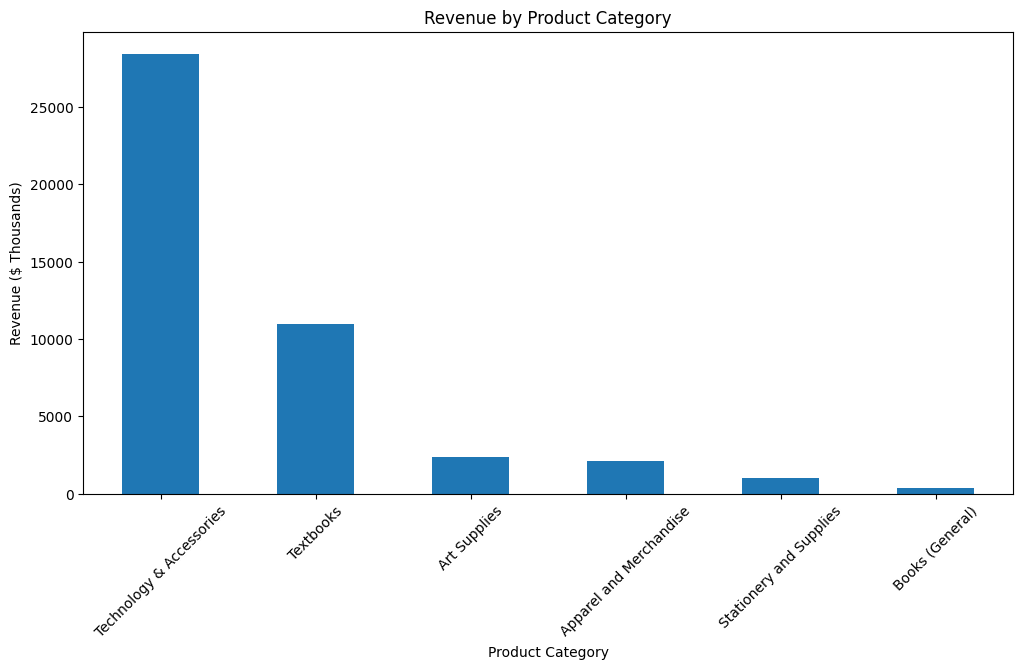

In [58]:
(top_categories / 1000).plot(kind="bar",figsize=(12,6))

plt.title("Revenue by Product Category")
plt.ylabel("Revenue ($ Thousands)")
plt.xlabel("Product Category")

plt.xticks(rotation=45)

plt.show()

# This chart compares total revenue by product category. 
# I used a bar chart because it clearly shows which categories generated the highest sales revenue.

### 6. What is your recommendation for where to focus marketing attention in the next quarter?

Based on the analysis of sales performance, customer spending, and product category revenue, I recommend focusing marketing efforts on the stores and product categories that consistently generated the highest revenue within Bo Heap's territory. These stores have already demonstrated strong customer demand and may provide the greatest return on investment for future marketing campaigns.

The product category analysis showed that certain categories generated significantly more revenue and transactions than others. This suggests that customers in the Massachusetts territory have clear purchasing preferences. Marketing campaigns should continue to promote high performing categories through targeted advertising, seasonal promotions, and loyalty program incentives.

The customer analysis also revealed that a small group of customers generated a large portion of total sales revenue. Because these customers are already rewards members, EmporiUm has an opportunity to strengthen customer retention through personalized offers, exclusive discounts, and loyalty rewards. Encouraging repeat purchases from existing high value customers may be more cost effective than acquiring new customers.

At the same time, lower performing product categories should not be ignored. Categories with lower transaction counts and revenue may represent opportunities for growth. Additional promotions, product bundling, or improved product visibility could help increase customer interest in these categories.

Overall, the data suggests that the most effective strategy for the next quarter is to continue investing in the strongest stores, promote the highest-performing product categories, and leverage rewards member data to increase customer loyalty and repeat purchases. This approach supports both short-term revenue growth and long-term customer retention.


In [60]:
store_detail["Territory Manager"].unique()

array(['Jim Heck', 'Ellen Lemon', 'Lana Ilana', 'Erbayne Middleton',
       'Shruti Reddy', 'Bo Heap', 'Miami Vue', 'See Ellefson',
       'Len Jensen', 'Jeff "Howdy" Richards'], dtype=object)

In [61]:
store_detail.head(20)

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers
5,Englewood,Colorado,706,Jim Heck,West,Cassie Chambers
6,Fort Collins,Colorado,707,Jim Heck,West,Cassie Chambers
7,Grand Junction,Colorado,708,Jim Heck,West,Cassie Chambers
8,Greeley,Colorado,709,Jim Heck,West,Cassie Chambers
9,Lafayette,Colorado,710,Jim Heck,West,Cassie Chambers
